<a href="https://colab.research.google.com/github/JhonatanMontalvo137/codigo-proyecto-terminal-UNADM/blob/main/Gravedad_FDM_2D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Patch
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection


=== CASO 1: Solo Tierra ===
Iteración 0, error = 4.71e-01
Convergió en 1348 iteraciones

=== CASO 2: Tierra + Luna ===
Iteración 0, error = 4.71e-01
Convergió en 1374 iteraciones


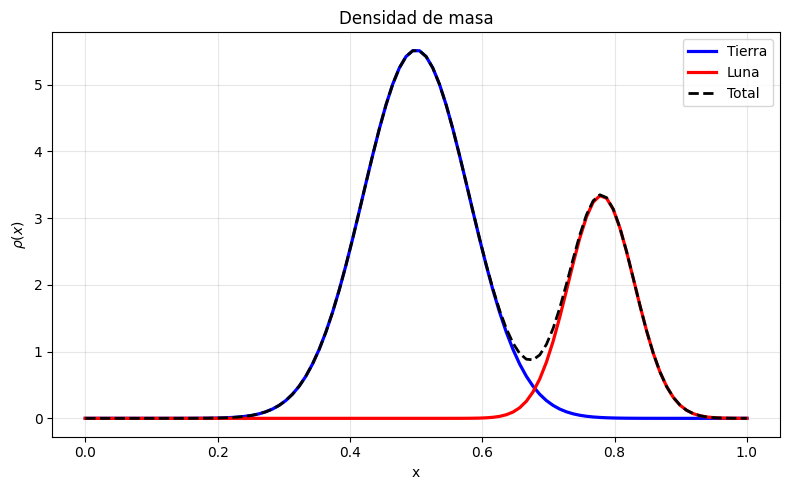

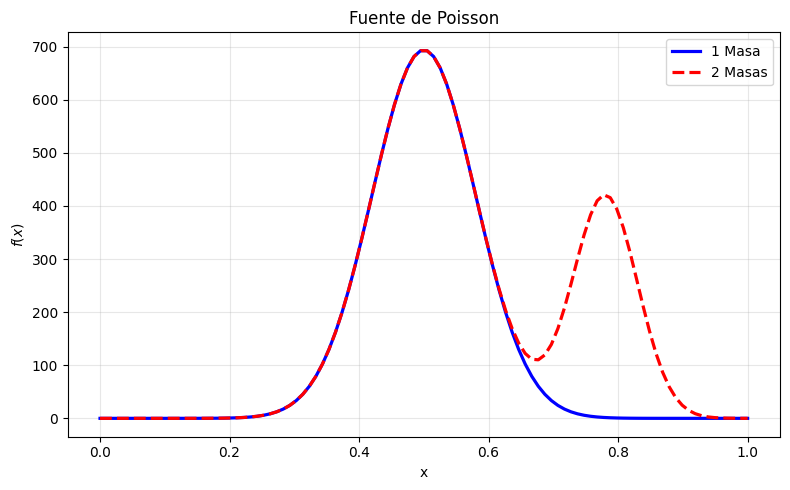

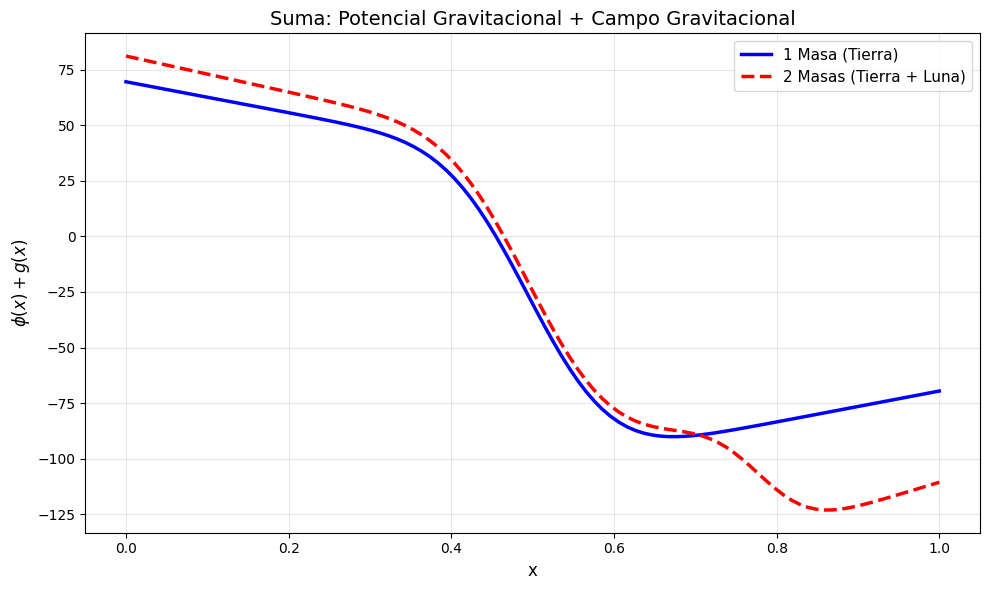

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# PARÁMETROS GENERALES
# =============================================
n = 100                    # número de puntos
xI, xF = 0.0, 1.0
x = np.linspace(xI, xF, n)
hx = (xF - xI) / (n - 1)

G = 10.0

# =============================================
# FUNCIÓN PARA RESOLVER POISSON EN 1D
# =============================================
def resolver_gravedad_1d(f):
    u = np.zeros(n)
    u[0] = 0
    u[-1] = 0

    max_iter = 10000
    tol = 1e-6
    omega = 1.8   # SOR

    for k in range(max_iter):
        u_old = u.copy()

        for i in range(1, n-1):
            u_new = 0.5 * (u[i+1] + u[i-1] - hx**2 * f[i])
            u[i] = (1 - omega) * u[i] + omega * u_new

        error = np.max(np.abs(u - u_old))
        if error < tol:
            print(f"Convergió en {k} iteraciones")
            break
        if k % 2000 == 0:
            print(f"Iteración {k}, error = {error:.2e}")

    return u

# =============================================
# CASO 1: UNA MASA (Tierra)
# =============================================
print("=== CASO 1: Solo Tierra ===")
xc_earth = 0.5
sigma = 0.08
density_earth = 5.52
rho_earth = density_earth * np.exp( - (x - xc_earth)**2 / (2*sigma**2) )

f1 = 4 * np.pi * G * rho_earth
u1 = resolver_gravedad_1d(f1)

# =============================================
# CASO 2: DOS MASAS (Tierra + Luna)
# =============================================
print("\n=== CASO 2: Tierra + Luna ===")
xc_moon = 0.78
sigma_moon = 0.05
density_moon = 3.34
rho_moon = density_moon * np.exp( - (x - xc_moon)**2 / (2*sigma_moon**2) )

rho_total = rho_earth + rho_moon
f2 = 4 * np.pi * G * rho_total
u2 = resolver_gravedad_1d(f2)

# =============================================
# GRÁFICAS
# =============================================

F1 = -np.gradient(u1, hx)
F2 = -np.gradient(u2, hx)

# 1. Densidad de masa
plt.figure(figsize=(8, 5))
plt.plot(x, rho_earth, 'b-', linewidth=2.3, label='Tierra')
plt.plot(x, rho_moon, 'r-', linewidth=2.3, label='Luna')
plt.plot(x, rho_total, 'k--', linewidth=2, label='Total')
plt.title('Densidad de masa')
plt.xlabel('x')
plt.ylabel(r'$\rho(x)$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Fuente de Poisson
plt.figure(figsize=(8, 5))
plt.plot(x, f1, 'b-', linewidth=2.3, label='1 Masa')
plt.plot(x, f2, 'r--', linewidth=2.3, label='2 Masas')
plt.title('Fuente de Poisson')
plt.xlabel('x')
plt.ylabel(r'$f(x)$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Potencial + Campo Gravitacional (Combinada)
suma1 = u1 + F1
suma2 = u2 + F2


plt.figure(figsize=(10, 6))

plt.plot(x, suma1, 'b-', linewidth=2.5, label='1 Masa (Tierra)')
plt.plot(x, suma2, 'r--', linewidth=2.5, label='2 Masas (Tierra + Luna)')

plt.title('Suma: Potencial Gravitacional + Campo Gravitacional', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel(r'$\phi(x) + g(x)$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [12]:
import numpy as np

# -----------------------------
# Parámetros del dominio
# -----------------------------
n = 100
xI, xF = 0, 1
yI, yF = 0, 1

x = np.linspace(xI, xF, n)
y = np.linspace(yI, yF, n)

hx = (xF - xI)/(n-1)
hy = (yF - yI)/(n-1)

X, Y = np.meshgrid(x, y)
# -----------------------------
# Inicialización
# -----------------------------
u = np.zeros((n, n))

# -----------------------------
# Fuente (Poisson) - pulso/masa
# ejemplo: masa en el centro
# -----------------------------

xc, yc = 0.5, 0.5
sigma  = 0.08
density_earth = 5.52


r2 = (X-xc)**2 + (Y-yc)**2

rho = density_earth * np.exp(-r2/(2*sigma**2))

G = 10.0
f = 4*np.pi*G*rho


# -----------------------------
# Condiciones de frontera tipo Dirichlet
# -----------------------------
u[:, 0]  = 0
u[:, -1] = 0
u[0, :]  = 0
u[-1, :] = 0   # ahora todo cerrado (más físico para Poisson)

# -----------------------------
# Iteración tipo SOR
# -----------------------------
max_iter = 10000
tol = 1e-5

omega = 1.8  # típicamente entre 1 y 2

for k in range(max_iter):
    u_old = u.copy()

    for i in range(1, n-1):
        for j in range(1, n-1):
            u_new = 0.25 * (
                u[i+1, j] +
                u[i-1, j] +
                u[i, j+1] +
                u[i, j-1]
                - hx**2 * f[i, j]
            )

            u[i, j] = (1 - omega) * u[i, j] + omega * u_new

    error = np.max(np.abs(u - u_old))

    if k % 500 == 0:
        print(f"Iteración {k}, error = {error:.6e}")

    if error < tol:
        print(f"Convergió en {k} iteraciones")
        break

Iteración 0, error = 2.550179e-01
Iteración 500, error = 4.995702e-04
Convergió en 923 iteraciones


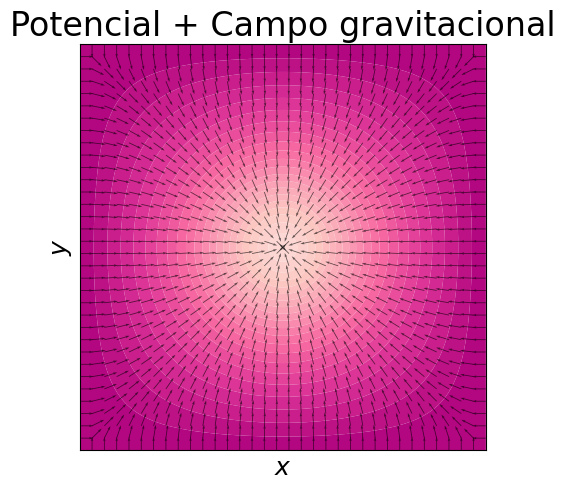

In [13]:
# -----------------------------
# Visualización
# -----------------------------

cmap = mpl.colormaps.get_cmap('RdPu')
cmap_soft = cm.colors.LinearSegmentedColormap.from_list('RdPu_soft',cmap(np.linspace(0.15, 0.75, 256)))

colors = [
    "#2b0033",  # muy oscuro (tipo jet inicio)
    "#800080",  # púrpura
    "#ffe6f2",   # rosa muy claro (casi blanco)
    "#ff66cc",  # rosa brillante
    "#cc00cc"  # magenta fuerte

]

cmap_pinkjet = LinearSegmentedColormap.from_list("pinkjet", colors, N=256)
# -----------------------------
# Malla (se asume que x, y ya existen)
# -----------------------------
X, Y = np.meshgrid(x, y)

# -----------------------------
# Gradiente del potencial
# -----------------------------
uy, ux = np.gradient(u, hx, hx)
Fx = -ux
Fy = -uy

# -----------------------------
# Normalización del campo
# -----------------------------
mag = np.sqrt(Fx**2 + Fy**2)
Fx = Fx / (mag + 1e-8)
Fy = Fy / (mag + 1e-8)

# -----------------------------
# Figura única
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 5))

skip = 3
fsize = 18

# Fondo: potencial
ax.contourf(X, Y, u, 20, cmap=cmap_soft, antialiased=True)

# Campo vectorial
ax.quiver(
    X[::skip, ::skip],
    Y[::skip, ::skip],
    Fx[::skip, ::skip],
    Fy[::skip, ::skip],
    color='black',
    angles='xy',
    scale_units='xy',
    scale=30,
    width=0.002,
    alpha=0.6
)

# Estética
ax.set_title("Potencial + Campo gravitacional", fontsize=24)
ax.set_xlabel(r'$x$', fontsize=fsize)
ax.set_ylabel(r'$y$', fontsize=fsize)
ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(labelsize=fsize)
ax.tick_params(bottom=False, left=False)
plt.tight_layout()
ax.set_aspect('equal', adjustable='box')
plt.show()



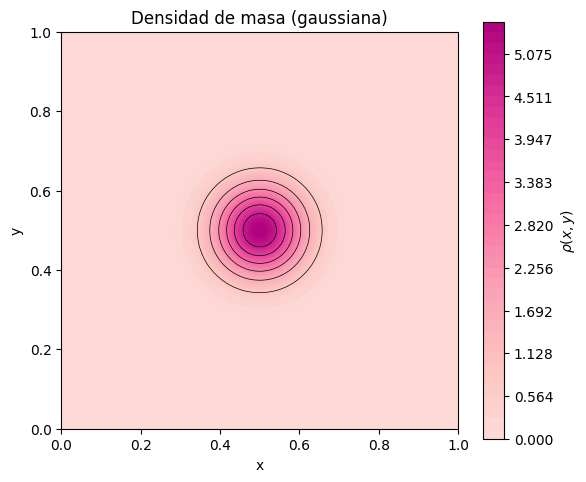

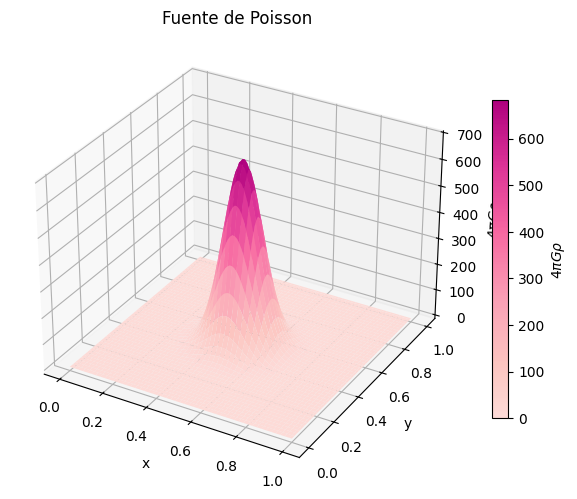

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D

# =============================
# Parámetros del dominio
# =============================
n = 100
xI, xF = 0, 1
yI, yF = 0, 1

x = np.linspace(xI, xF, n)
y = np.linspace(yI, yF, n)

hx = (xF - xI)/(n-1)
hy = (yF - yI)/(n-1)

X, Y = np.meshgrid(x, y)

# =============================
# Fuente: masa gaussiana
# =============================
# Fuente (Poisson) - densidades reales (adimensionales)

xc, yc = 0.5, 0.5
sigma  = 0.08
density_earth = 5.52


r2 = (X-xc)**2 + (Y-yc)**2

rho = density_earth * np.exp(-r2/(2*sigma**2))

G = 10.0
f = 4*np.pi*G*rho



# =============================
# Visualización 2D (rho)
# =============================
fig, ax = plt.subplots(figsize=(6, 5))

cf = ax.contourf(X, Y, rho, levels=np.linspace(0, rho.max(), 40), cmap=cmap_soft)
ax.contour(X, Y, rho, colors='k', linewidths=0.5)

cbar = plt.colorbar(cf, ax=ax)
cbar.set_label(r'$\rho(x,y)$')

ax.set_title("Densidad de masa (gaussiana)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# =============================
# Visualización 3D (f)
# =============================
fig = plt.figure(figsize=(6, 5))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, f, cmap=cmap_soft, antialiased=True)

fig.colorbar(surf, ax=ax, shrink=0.7, label=r'$4\pi G \rho$')

ax.set_title("Fuente de Poisson")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel(r'$4\pi G \rho$')

plt.tight_layout()
plt.show()

In [15]:
import numpy as np

# -----------------------------
# Parámetros del dominio
# -----------------------------
n = 100
xI, xF = 0, 1
yI, yF = 0, 1

x = np.linspace(xI, xF, n)
y = np.linspace(yI, yF, n)

hx = (xF - xI)/(n-1)

X, Y = np.meshgrid(x, y)

# -----------------------------
# Inicialización
# -----------------------------
u = np.zeros((n, n))

# -----------------------------
# Dos masas (gaussianas)
# -----------------------------
G = 10.0

# Masa 1 Tierra
x1, y1 = 0.3, 0.3
sigma1 = 0.08
density_earth = 5.52

# Masa 2 Luna
x2, y2 = 0.7, 0.7
sigma2 = 0.05
density_moon = 3.34

# -----------------------------
# Construcción de rho
# -----------------------------
r1_2 = (X-x1)**2 + (Y-y1)**2
r2_2 = (X-x2)**2 + (Y-y2)**2

rho1 = density_earth * np.exp(-r1_2/(2*sigma1**2))
rho2 = density_moon * np.exp(-r2_2/(2*sigma2**2))

rho = rho1 + rho2

# -----------------------------
# Lado derecho de Poisson
# -----------------------------
f = 4*np.pi*G*rho
# -----------------------------
# Condiciones de frontera
# -----------------------------
u[:, 0]  = 0
u[:, -1] = 0
u[0, :]  = 0
u[-1, :] = 0

# -----------------------------
# Iteración tipo SOR
# -----------------------------
max_iter = 10000
tol = 1e-5

omega = 1.8  # típicamente entre 1 y 2

for k in range(max_iter):
    u_old = u.copy()

    for i in range(1, n-1):
        for j in range(1, n-1):
            u_new = 0.25 * (
                u[i+1, j] +
                u[i-1, j] +
                u[i, j+1] +
                u[i, j-1]
                - hx**2 * f[i, j]
            )

            u[i, j] = (1 - omega) * u[i, j] + omega * u_new

    error = np.max(np.abs(u - u_old))

    if k % 500 == 0:
        print(f"Iteración {k}, error = {error:.6e}")

    if error < tol:
        print(f"Convergió en {k} iteraciones")
        break

Iteración 0, error = 2.552777e-01
Iteración 500, error = 3.718135e-04
Convergió en 891 iteraciones


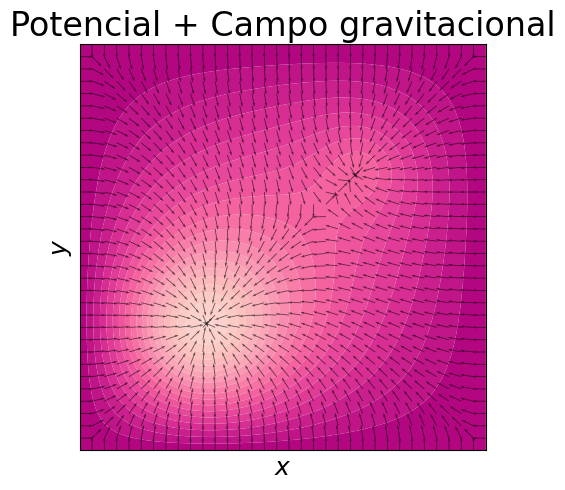

In [16]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
# -----------------------------
# Visualización
# -----------------------------

cmap = mpl.colormaps.get_cmap('RdPu')
cmap_soft = cm.colors.LinearSegmentedColormap.from_list('RdPu_soft',cmap(np.linspace(0.15, 0.75, 256)))

colors = [
    "#2b0033",  # muy oscuro (tipo jet inicio)
    "#800080",  # púrpura
    "#ffe6f2",   # rosa muy claro (casi blanco)
    "#ff66cc",  # rosa brillante
    "#cc00cc"  # magenta fuerte

]

cmap_pinkjet = LinearSegmentedColormap.from_list("pinkjet", colors, N=256)
# -----------------------------
# Malla (se asume que x, y ya existen)
# -----------------------------
X, Y = np.meshgrid(x, y)

# -----------------------------
# Gradiente del potencial
# -----------------------------
uy, ux = np.gradient(u, hx, hx)
Fx = -ux
Fy = -uy

# -----------------------------
# Normalización del campo
# -----------------------------
mag = np.sqrt(Fx**2 + Fy**2)
Fx = Fx / (mag + 1e-8)
Fy = Fy / (mag + 1e-8)

# -----------------------------
# Figura única
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 5))

skip  = 3
fsize = 18

# Fondo: potencial
ax.contourf(X, Y, u, 20, cmap=cmap_soft, antialiased=True)

# Campo vectorial
ax.quiver(
    X[::skip, ::skip],
    Y[::skip, ::skip],
    Fx[::skip, ::skip],
    Fy[::skip, ::skip],
    color='black',
    angles='xy',
    scale_units='xy',
    scale=30,
    width=0.002,
    alpha=0.6
)

# Estética
ax.set_title("Potencial + Campo gravitacional", fontsize=24)
ax.set_xlabel(r'$x$', fontsize=fsize)
ax.set_ylabel(r'$y$', fontsize=fsize)
ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(labelsize=fsize)
ax.tick_params(bottom=False, left=False)
plt.tight_layout()
ax.set_aspect('equal', adjustable='box')
plt.show()

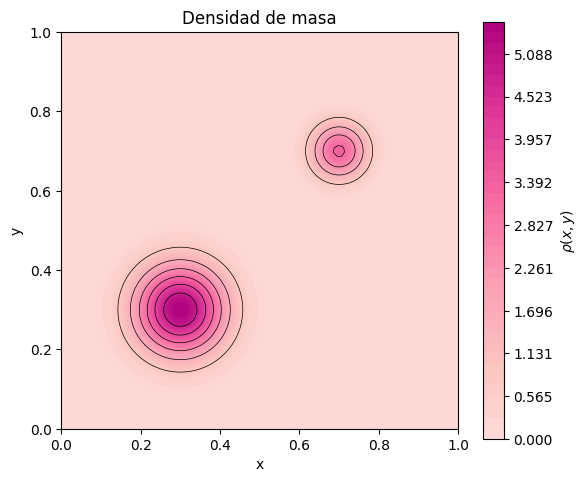

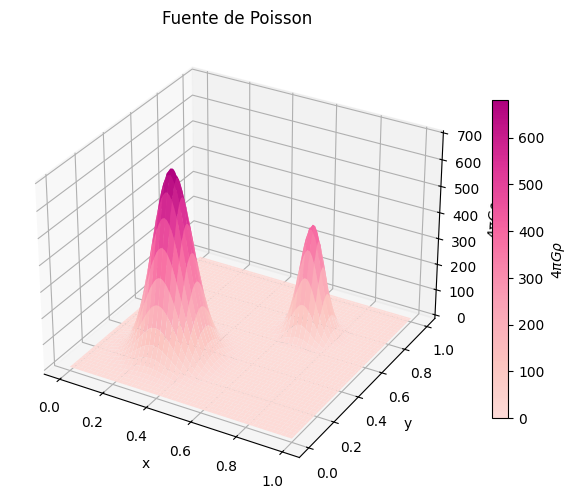

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D

# -----------------------------
# Parámetros del dominio
# -----------------------------
n = 100
xI, xF = 0, 1
yI, yF = 0, 1

x = np.linspace(xI, xF, n)
y = np.linspace(yI, yF, n)

hx = (xF - xI)/(n-1)

X, Y = np.meshgrid(x, y)

# -----------------------------
# Parámetros físicos
# -----------------------------
G = 10.0

# Masa 1
x1, y1 = 0.3, 0.3
sigma1 = 0.08
density_earth = 5.52

# Masa 2
x2, y2 = 0.7, 0.7
sigma2 = 0.05
density_moon = 3.34

# -----------------------------
# Construcción de rho
# -----------------------------
r1_2 = (X-x1)**2 + (Y-y1)**2
r2_2 = (X-x2)**2 + (Y-y2)**2

rho1 = density_earth * np.exp(-r1_2/(2*sigma1**2))
rho2 = density_moon * np.exp(-r2_2/(2*sigma2**2))

rho = rho1 + rho2

# -----------------------------
# Lado derecho de Poisson
# -----------------------------
f = 4*np.pi*G*rho



# =============================
# Visualización 2D (rho)
# =============================
fig, ax = plt.subplots(figsize=(6, 5))

cf = ax.contourf(X, Y, rho, levels=np.linspace(0, rho.max(), 40), cmap=cmap_soft)
ax.contour(X, Y, rho, colors='k', linewidths=0.5)

cbar = plt.colorbar(cf, ax=ax)
cbar.set_label(r'$\rho(x,y)$')

ax.set_title("Densidad de masa")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# =============================
# Visualización 3D (f)
# =============================
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, f, cmap=cmap_soft, antialiased=True)

fig.colorbar(surf, ax=ax, shrink=0.7, label=r'$4\pi G \rho$')

ax.set_title("Fuente de Poisson")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel(r'$4\pi G \rho$')

plt.tight_layout()
plt.show()